In [1]:
#logistic regression carbapenemase classifier
import pandas as pd 
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import random
import json
from copy import deepcopy
import warnings
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# DEVICE = "mps" #mac graphics card
EMB_TYPE = "CLSEmbedding"  # or "CLSEmbedding"
warnings.filterwarnings("ignore")
print("DEVICE:", DEVICE)
print("EMB_TYPE:", EMB_TYPE)

DEVICE: cpu
EMB_TYPE: CLSEmbedding


In [2]:
df = pd.read_csv("embeddings.csv")
df.head()

,Family,Gene,Sequence,Carbapenemase,MeanEmbedding,CLSEmbedding,EmbeddingDim
0,SHV,SHV-52,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,0,"[[0.05962217226624489, -0.07687947154045105, 0...","[[0.07300693541765213, -0.0206560418009758, 0....",1280
1,CTX-M,CTX-M-130,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,0,"[[0.05877629667520523, -0.06891713291406631, -...","[[0.10748688131570816, -0.044926486909389496, ...",1280
2,NDM,NDM-6,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,1,"[[0.011112090200185776, -0.0261966772377491, -...","[[0.09951694309711456, -0.028426654636859894, ...",1280
3,ACT,ACT-35,MMKKSLCCALLLGISCSALATPVSEKQLAEVVANTVTPLMKAQSVP...,0,"[[0.020459039136767387, -0.09762255847454071, ...","[[0.06834391504526138, -0.0660293847322464, 0....",1280
4,TEM,TEM-126,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,0,"[[0.059695929288864136, -0.05530138313770294, ...","[[0.07826980203390121, -0.01159658282995224, 0...",1280


In [3]:
#prepare dataset:
X = np.vstack(df[EMB_TYPE].apply(lambda x: np.fromstring(x.strip("[]"), sep=" ")))
y = df["Carbapenemase"].values

#scale features
X_scaled = StandardScaler().fit_transform(X)

In [4]:
# 5 fold cv
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
metrics = {
    "fold": [],
    "accuracy": [],
    "balanced_accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": [],
    "avg_precision": []
}

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = make_pipeline(StandardScaler(), LogisticRegression(random_state=SEED, class_weight="balanced", max_iter=5000))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics["fold"].append(fold + 1)
    metrics["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["balanced_accuracy"].append(balanced_accuracy_score(y_test, y_pred))
    metrics["precision"].append(precision_score(y_test, y_pred))
    metrics["recall"].append(recall_score(y_test, y_pred))
    metrics["f1"].append(f1_score(y_test, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_test, y_prob))
    metrics["avg_precision"].append(average_precision_score(y_test, y_prob))
metrics_df = pd.DataFrame(metrics)
metrics_df

,fold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,avg_precision
0,1,0.479256,0.519545,0.309927,0.618357,0.412903,0.583962,0.410187
1,2,0.513591,0.566322,0.342043,0.695652,0.458599,0.643337,0.427585
2,3,0.538682,0.567313,0.348285,0.637681,0.450512,0.616557,0.431258
3,4,0.498567,0.508063,0.303030,0.531401,0.385965,0.531303,0.349341
4,5,0.511461,0.542376,0.328205,0.618357,0.428811,0.591842,0.397163


In [5]:
metrics_df.to_csv(f"log_reg_metrics_{EMB_TYPE}.csv", index=False)

In [6]:
# get prediction probabilities for all samples
y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# find best threshold based on F1 score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_scores[best_idx])

Best threshold: 0.5289582329859525
Precision: 0.5525114155251142
Recall: 0.5845410628019324
F1: 0.5680751173209317


In [7]:
# retrain with new threshold:
# 5 fold cv
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
metrics = {
    "fold": [],
    "accuracy": [],
    "balanced_accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": [],
    "avg_precision": []
}

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = make_pipeline(StandardScaler(), LogisticRegression(random_state=SEED, class_weight="balanced", max_iter=5000))
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)

    metrics["fold"].append(fold + 1)
    metrics["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["balanced_accuracy"].append(balanced_accuracy_score(y_test, y_pred))
    metrics["precision"].append(precision_score(y_test, y_pred))
    metrics["recall"].append(recall_score(y_test, y_pred))
    metrics["f1"].append(f1_score(y_test, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_test, y_prob))
    metrics["avg_precision"].append(average_precision_score(y_test, y_prob))
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(f"log_reg_metrics_threshold_{EMB_TYPE}.csv", index=False)

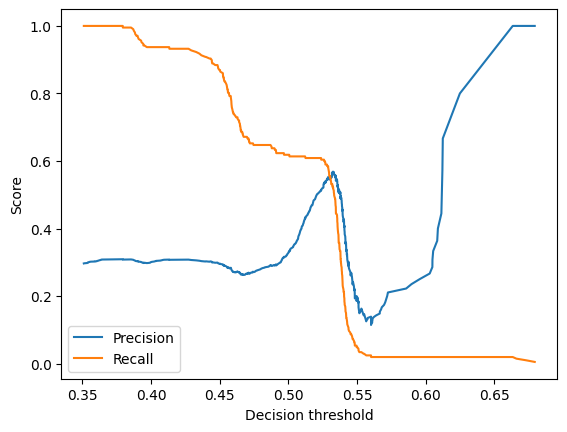

In [8]:
# plot precision-recall curve
import matplotlib.pyplot as plt

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [9]:
# confusion matrix all folds together
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

# cross-validated probabilities
y_prob = cross_val_predict(
    make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=5000)),
    X,
    y,
    cv=5,
    method="predict_proba"
)[:,1]

# apply tuned threshold
y_pred = (y_prob >= best_threshold).astype(int)

cm = confusion_matrix(y, y_pred)
print(cm)

[[1963  494]
 [ 721  314]]


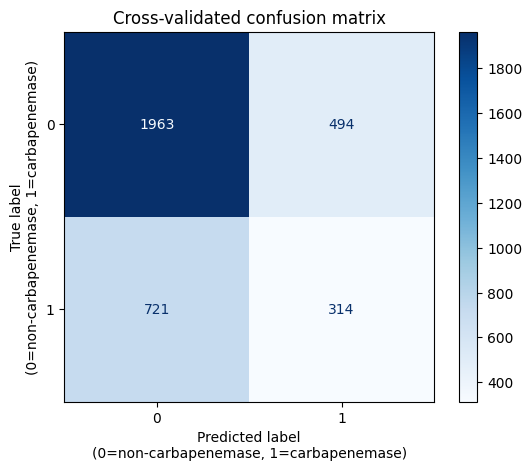

In [10]:
#plot cm
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.ylabel("True label\n(0=non-carbapenemase, 1=carbapenemase)")
plt.xlabel("Predicted label\n(0=non-carbapenemase, 1=carbapenemase)")
plt.title("Cross-validated confusion matrix")
plt.show()

In [11]:
# train final model on all data with best threshold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

final_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=SEED
    )
)

final_model.fit(X_scaled, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    random_state=42))])

In [12]:
# inference with final model
y_prob = final_model.predict_proba(X_scaled)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

final_cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(final_cm)

Confusion Matrix:
[[1918  539]
 [ 423  612]]


In [13]:
# classification metrics
final_metrics = classification_report(y, y_pred, output_dict=True)

# add AUROC and AUPRC
final_metrics["AUROC"] = {"score": roc_auc_score(y, y_prob)}
final_metrics["AUPRC"] = {"score": average_precision_score(y, y_prob)}
final_metrics["balanced_accuracy"] = {"score": balanced_accuracy_score(y, y_pred)}

# convert to dataframe
final_metrics_df = pd.DataFrame(final_metrics).transpose()

# save
final_metrics_df.to_csv(f"log_reg_final_metrics_{EMB_TYPE}.csv", index=True)

print(final_metrics_df)

                   precision    recall  f1-score      support     score
0                   0.819308  0.780627  0.799500  2457.000000       NaN
1                   0.531712  0.591304  0.559927  1035.000000       NaN
accuracy            0.724513  0.724513  0.724513     0.724513  0.724513
macro avg           0.675510  0.685966  0.679713  3492.000000       NaN
weighted avg        0.734067  0.724513  0.728492  3492.000000       NaN
AUROC                    NaN       NaN       NaN          NaN  0.593490
AUPRC                    NaN       NaN       NaN          NaN  0.400848
balanced_accuracy        NaN       NaN       NaN          NaN  0.685966


In [14]:
# is the model learning carb function or just family membership?
import umap

reducer = umap.UMAP(random_state=SEED,
                    n_neighbors=30,
                    min_dist=0.1,
                    )

embedding = reducer.fit_transform(X_scaled)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


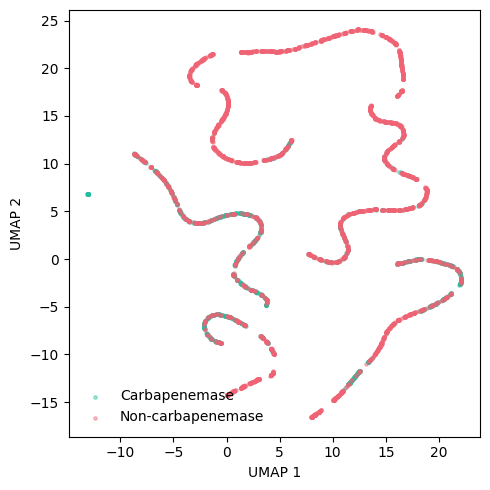

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5, 5))

colors = {
    1: "#20BD9F",   # carbapenemase
    0: "#F06374"    # non-carbapenemase
}

labels = {
    1: "Carbapenemase",
    0: "Non-carbapenemase"
}

for cls in [1, 0]:
    mask = (y == cls)
    plt.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        label=labels[cls],
        alpha=0.4,
        s=6,
        c=colors[cls]
    )

plt.legend(
    frameon=False,
    fontsize=10,
    loc="best"
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

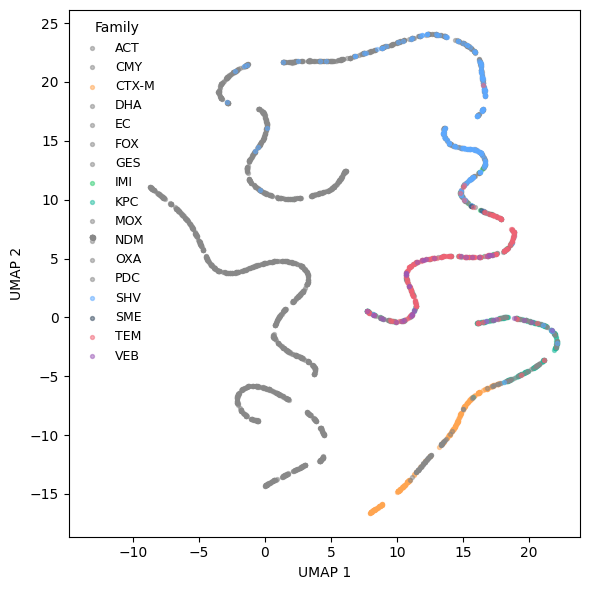

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# If Family is a pandas column
families = df["Family"].values

unique_families = np.unique(families)

# Simple color palette (extend if needed)
colors = {
    "KPC": "#20BD9F",
    "TEM": "#F06374",
    "SHV": "#5DA9FF",
    "CTX-M": "#FFA550",
    "VEB": "#9B59B6",
    "IMI": "#2ECC71",
    "SME": "#34495E"
}

plt.figure(figsize=(6,6))

for fam in unique_families:
    mask = families == fam
    plt.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        label=fam,
        s=8,
        alpha=0.5,
        c=colors.get(fam, "#888888")
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.legend(
    title="Family",
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()